In [1]:
import numpy as np
import xroms
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import warnings
import sys
import xrft
sys.path.append("/homes/metogra/iufarias/FeedbackSubmeso/useful/")
import romspickle
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import datetime
import cmocean as cm
# from dask.diagnostics import ProgressBar
# import dask
# dask.config.set(**{'array.slicing.split_large_chunks': True})
# from dask.distributed import Client, LocalCluster
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as PathEffects

warnings.filterwarnings("ignore")

import seawater as sw
import matplotlib.gridspec as gridspec

In [2]:
def Dist_Calc(lon,lat):
    'distance between each point in km'
    dx_km=sw.dist(lon=lon,lat=lat)[0]
    dx_dist=np.insert(dx_km,0,0)
    return np.cumsum(dx_dist)

In [3]:
# # client = Client(n_workers=90)
# # # client = Client(cluster)

# client = Client(n_workers=30,processes=True)
# client

## Reading WRF(3D)

In [4]:
# chunks={'time_counter':1}

# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2012M05.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2012M05_DAY.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2012M05.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2012M04.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2011M06.nc',data_vars='minimal')


varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2011M10.nc',data_vars='minimal')
# vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrfout_',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2011M10.nc',data_vars='minimal')


In [7]:
!rm /homes/metogra/iufarias/.cache/matplotlib/fontlist*

plt.rcParams.update({'font.size': 14})
# plt.rcParams.update({'font.weight': 'bold'})
# plt.rc('font',**{'family':'serif','serif':['Helvetica']})

plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Lucida Grande']
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.linewidth'] = 1.1

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True

props = dict(boxstyle='round', facecolor='wheat', alpha=1)


rm: cannot remove '/homes/metogra/iufarias/.cache/matplotlib/fontlist*': No such file or directory


In [8]:
import xesmf as xe
    
def regrid(var, lons, lats, which):
    # rename coords for use with xESMF
    lonkey = [coord for coord in var.coords if "nav_lon" in coord][0]
    latkey = [coord for coord in var.coords if "nav_lat" in coord][0]
    var = var.rename({lonkey: "lon", latkey: "lat"})

    # whether inputs are
    if which == "pairs":
        locstream_out = True
    elif which == "grid":
        locstream_out = False

    # set up for output
    varint = xr.Dataset({"lat": (["y", "x"], lats), "lon": (["y", "x"], lons)})

    # Calculate weights.
    regridder = xe.Regridder(var, varint, "bilinear",  locstream_out=locstream_out)

    # Perform interpolation
    varint = regridder(var, keep_attrs=True)
    return varint, regridder



## Analysis

In [9]:
w_full=varfw.W.compute().isel(x_grid_M=slice(0,220))
t_air_full=varfw.T.compute().isel(x_grid_M=slice(0,220))+300 -273.15
sst_full=varfw.SST.compute().isel(x_grid_M=slice(0,220))-273.15
pbl_full=varfw.PBLH.compute().isel(x_grid_M=slice(0,220))

In [10]:
u_full_g=varfw.U.compute()
v_full_g=varfw.V.compute()

u_full=((u_full_g[:,:,:,1:] + u_full_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,220))
v_full=((v_full_g[:,:,1:,:] + v_full_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,220))

div_full=u_full.differentiate('x_grid_U')/2e3 + v_full.differentiate('y_grid_V').values/2e3
# u_smth_g=vartw.U.compute()
# v_smth_g=vartw.V.compute()

# u_smth=((u_smth_g[:,:,:,1:] + u_smth_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,220))
# v_smth=((v_smth_g[:,:,1:,:] + v_smth_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,220))

In [11]:
lat_rho=w_full['nav_lat_grid_M']
lon_rho=w_full['nav_lon_grid_M']

### Instantaneous plots (Example 1)

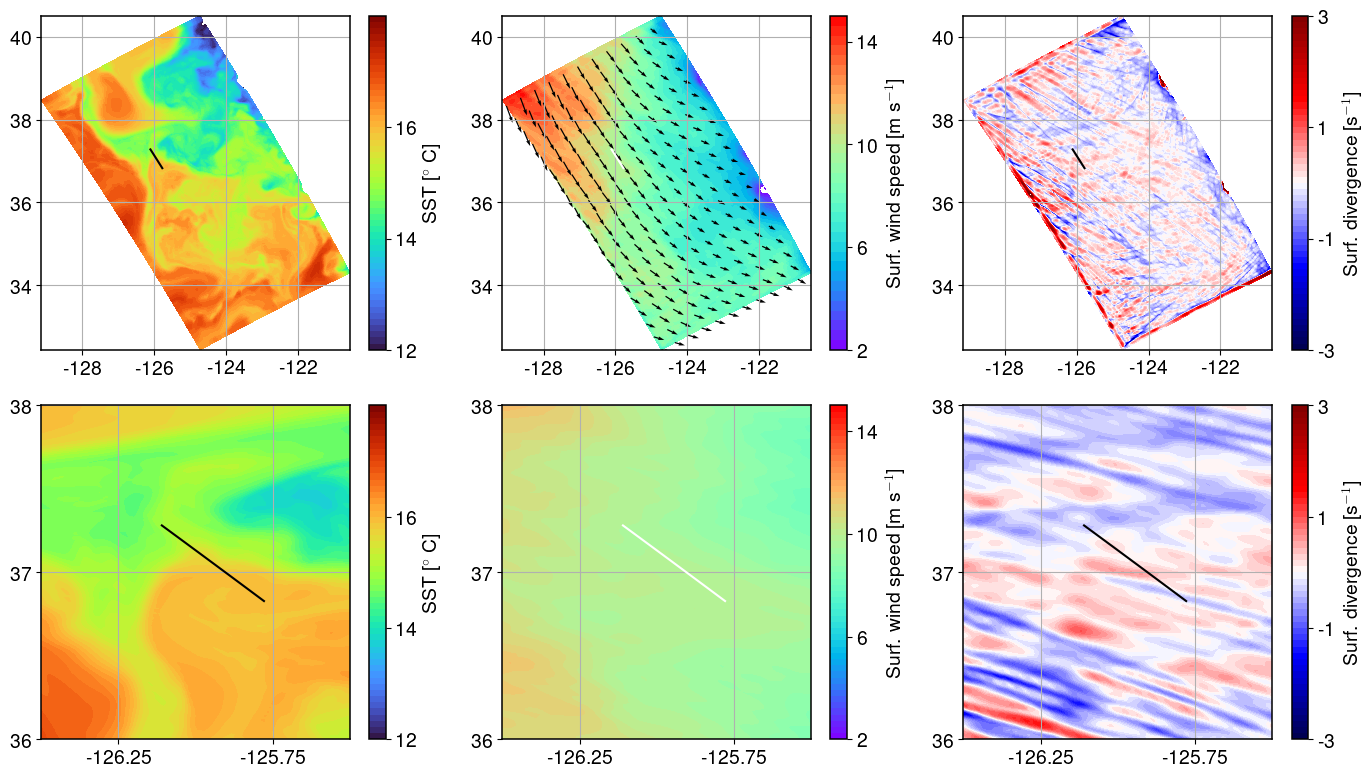

In [26]:
day_s=4

x_sta_lim=79
x_end_lim=80

y_sta_lim=235
y_end_lim=265

tmin=12
tmax=18

windmin=2
windmax=15

divmin=-3
divmax=3


wmin=-1
wmax=1


wmin=-1
wmax=1
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
# (sst_full-273.15)[1].plot(

c1=plt.contourf(lon_rho,lat_rho,(sst_full).isel(time_counter=day_s),levels=np.linspace(tmin,tmax,55),cmap='turbo')
cb1=plt.colorbar(c1,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')
cb1.ax.set_yticklabels(np.arange(tmin,tmax,2).astype(str))

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()
plt.yticks([34,36,38,40],labels=np.array([34,36,38,40]))
plt.xticks([-128,-126,-124,-122],labels=np.array([-128,-126,-124,-122]).astype(str))


plt.title('')
plt.subplot(2,3,2)
dec=20
c2=plt.contourf(lon_rho,lat_rho,
    (np.sqrt(u_full.isel(lev_M=1,time_counter=day_s)**2 + v_full.isel(lev_M=1,time_counter=day_s).values**2)),
             levels=np.linspace(windmin,windmax,35),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')


cb2=plt.colorbar(c2,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

cb2.ax.set_yticklabels(np.arange(windmin,windmax,4).astype(str))


plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
           u_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],
           v_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec])
plt.title('')
plt.grid()

plt.yticks([34,36,38,40],labels=np.array([34,36,38,40]))
plt.xticks([-128,-126,-124,-122],labels=np.array([-128,-126,-124,-122]).astype(str))

plt.subplot(2,3,3)
# c5=plt.contourf(lon_rho,lat_rho,
#                 (w_full).isel(lev_W=1,time_counter=day_s)*100,levels=np.linspace(wmin,wmax,55),cmap='seismic',extend='both')
# plt.colorbar(c5,ticks=np.arange(wmin,wmax+2,2),label=r'Surf. w [cm s$^{-1}$]')
# plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
#          lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')


c5=plt.contourf(lon_rho,lat_rho,
                (div_full).isel(lev_M=1,time_counter=day_s)*1e4,levels=np.linspace(divmin,divmax,55),cmap='seismic')
cb5=plt.colorbar(c5,ticks=np.arange(divmin,divmax+2,2),label=r'Surf. divergence [s$^{-1}$]')
cb5.ax.set_yticklabels(np.arange(divmin,divmax+2,2).astype(str))

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.yticks([34,36,38,40],labels=np.array([34,36,38,40]))
plt.xticks([-128,-126,-124,-122],labels=np.array([-128,-126,-124,-122]).astype(str))

plt.subplot(2,3,4)
# (sst_full-273.15)[1].plot(

c1=plt.contourf(lon_rho,lat_rho,(sst_full).isel(time_counter=day_s),levels=np.linspace(tmin,tmax,55),cmap='turbo')
cb1=plt.colorbar(c1,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')
cb1.ax.set_yticklabels(np.arange(tmin,tmax,2).astype(str))

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.ylim(36,38)
plt.xlim(-126.5,-125.5)
plt.yticks([36,37,38],labels=np.array([36,37,38]).astype(str))
plt.xticks([-126.25,-125.75],labels=np.array([-126.25,-125.75]).astype(str))

plt.title('')
plt.subplot(2,3,5)
dec=10
c2=plt.contourf(lon_rho,lat_rho,
    (np.sqrt(u_full.isel(lev_M=1,time_counter=day_s)**2 + v_full.isel(lev_M=1,time_counter=day_s).values**2)),
             levels=np.linspace(windmin,windmax,55),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')


cb2=plt.colorbar(c2,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

cb2.ax.set_yticklabels(np.arange(windmin,windmax,4).astype(str))

# plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
#            u_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],
#            v_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],scale=100)
plt.title('')
plt.grid()
plt.ylim(36,38)
plt.xlim(-126.5,-125.5)
plt.yticks([36,37,38],labels=np.array([36,37,38]).astype(str))
plt.xticks([-126.25,-125.75],labels=np.array([-126.25,-125.75]).astype(str))


plt.subplot(2,3,6)

c5=plt.contourf(lon_rho,lat_rho,
                (div_full).isel(lev_M=1,time_counter=day_s)*1e4,levels=np.linspace(divmin,divmax,55),cmap='seismic')
cb5=plt.colorbar(c5,ticks=np.arange(divmin,divmax+2,2),label=r'Surf. divergence [s$^{-1}$]')
cb5.ax.set_yticklabels(np.arange(divmin,divmax+2,2).astype(str))

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.ylim(36,38)
plt.xlim(-126.5,-125.5)
plt.yticks([36,37,38],labels=np.array([36,37,38]).astype(str))
plt.xticks([-126.25,-125.75],labels=np.array([-126.25,-125.75]).astype(str))


plt.tight_layout()

In [27]:
Altitude=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim))#.squeeze()
Altitude_m=(Altitude[:,1:].data +  Altitude[:,:-1])/2

Z=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(0,220))
Z_m=Z[:,1:,:,:].data/2 + Z[:,:-1,:,:]/2


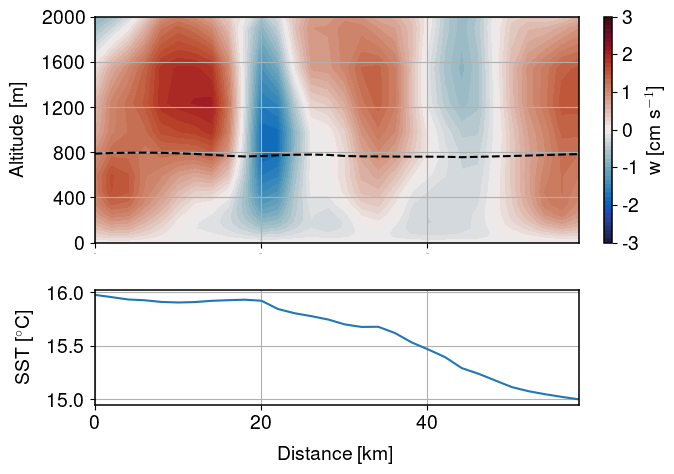

In [28]:
# wmin=-1
# wmax=1
wmin=-3
wmax=3

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

ylim=2000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])

cb2=plt.contourf(sec_dist,
             Altitude.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             w_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()*100,
                 levels=np.linspace(wmin,wmax,55),cmap=cm.cm.balance)


plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='k',linestyle='--')

plt.grid()

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(wmin,wmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical',label=r'w [cm s$^{-1}$]')

cbar2.ax.set_yticklabels(np.arange(wmin,wmax+1,1).astype(str))

ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

SST_sec=sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()

plt.plot(sec_dist,SST_sec)
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),2).astype(str))
# ax3.set_ylim(SST_sec.min(),SST_sec.max())

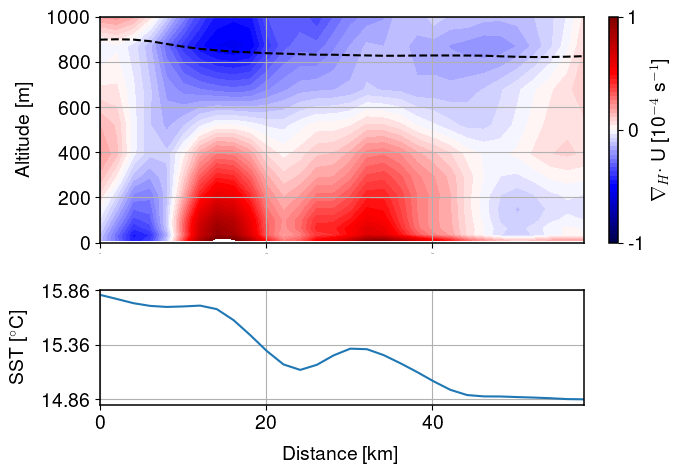

In [25]:

divmin=-1
divmax=1

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])


cb2=plt.contourf(sec_dist,
             Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             div_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                         y_grid_U=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()*1e4,
                 levels=np.linspace(divmin,divmax,55),cmap='seismic')
plt.grid()



plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='k',linestyle='--')


cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(divmin,divmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical',label=r'$\nabla_H \cdot$ U [10$^{-4}$ s$^{-1}$]')
cbar2.ax.set_yticklabels(np.arange(divmin,divmax+1,1).astype(str))


ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),2).astype(str))


In [16]:
# dudz=np.gradient(u_full,
#                  axis=1)/np.gradient(Z_m,axis=1)
# dvdz=np.gradient(v_full,
#                  axis=1)/np.gradient(Z_m,axis=1);VWS_label=r'Vertical wind \\ shear[10$^{-2}$ s$^{-1}$]' #total


dudz=np.gradient(u_full- u_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                                     y_grid_U=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_U','x_grid_U']).values[None,:,None,None],
                 axis=1)/np.gradient(Z_m,axis=1)
dvdz=np.gradient(v_full - v_full.isel(x_grid_V=slice(x_sta_lim,x_end_lim),
                                     y_grid_V=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_V','x_grid_V']).values[None,:,None,None],
                 axis=1)/np.gradient(Z_m,axis=1);VWS_label=r'Vertical wind \\ shear anomaly [10$^{-2}$ s$^{-1}$]' #anomaly

vshear_full=u_full.copy(data=np.sqrt(dudz**2 + dvdz**2)).isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                         y_grid_U=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()

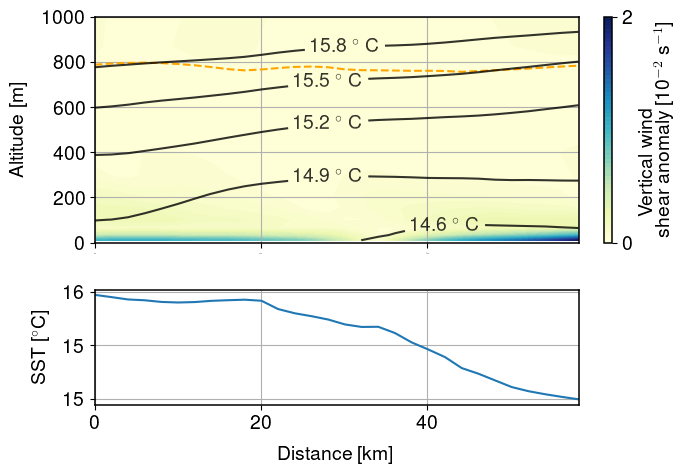

In [17]:

vwsmin=0
vwsmax=2

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

tair_min=14
tair_max=16

ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])


cb2=plt.contourf(sec_dist,
             Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             vshear_full*1e2,
                 levels=np.linspace(vwsmin,vwsmax,55),cmap='YlGnBu')
plt.grid()

plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='orange',linestyle='--')


cc=plt.contour(sec_dist,
               Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
               t_air_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),levels=np.arange(tair_min,tair_max,0.3),colors='k',alpha=0.8)
cbr0=plt.clabel(cc, cc.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$ C')

# cbr0=ax0.clabel(cr0, cr0.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$C')
# plt.setp(cc, path_effects=[PathEffects.withStroke(linewidth=0.8,alpha=0.8, foreground="c")])

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(vwsmin,vwsmax+2,2),
                   pad=1,shrink=0.002,orientation='vertical',label=VWS_label)
cbar2.ax.set_yticklabels(np.arange(vwsmin,vwsmax+2,2).astype(str))

ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(15,16.5,0.5),labels=np.arange(15,16.5,0.5).astype(int).astype(str))



In [256]:
u_anom_full=(u_full- u_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                                     y_grid_U=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_U','x_grid_U']).values[None,:,None,None])

v_anom_full=(v_full- v_full.isel(x_grid_V=slice(x_sta_lim,x_end_lim),
                                     y_grid_V=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_V','x_grid_V']).values[None,:,None,None])

# wspeed_full= np.sqrt(u_anom_full**2 + v_anom_full.values**2);WS_label=r'Wind speed anomaly [m s$^{-1}$]'

wspeed_full=np.sqrt(u_full**2+v_full.values**2);WS_label=r'Wind speed [m s$^{-1}$]'

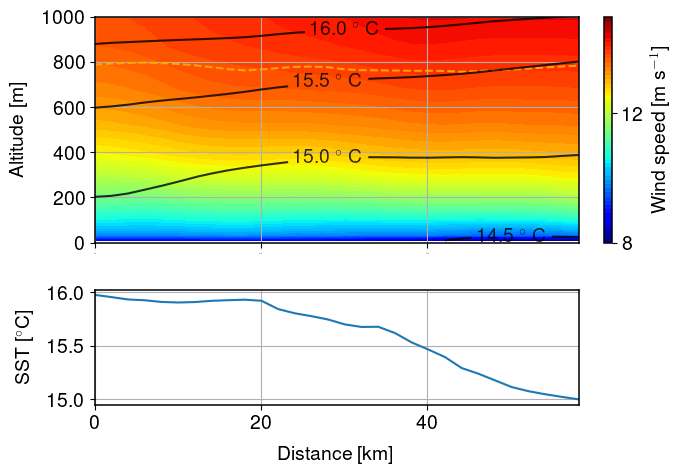

In [264]:

wmin=8
wmax=15

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

tair_min=14
tair_max=16.5
tair_diff=0.5



ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])


cb2=plt.contourf(sec_dist,
             Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             wspeed_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                         y_grid_U=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),
                 levels=np.linspace(wmin,wmax,55),cmap='jet')
plt.grid()

plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='orange',linestyle='--')


cc=plt.contour(sec_dist,
               Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
               t_air_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),levels=np.arange(tair_min,tair_max,tair_diff),colors='k',alpha=0.8)
cbr0=plt.clabel(cc, cc.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$ C')

# cbr0=ax0.clabel(cr0, cr0.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$C')
# plt.setp(cc, path_effects=[PathEffects.withStroke(linewidth=0.8,alpha=0.8, foreground="c")])

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(wmin,wmax+4,4),
                   pad=1,shrink=0.002,orientation='vertical',label=WS_label)
cbar2.ax.set_yticklabels(np.arange(wmin,wmax+4,4).astype(str))

ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),2).astype(str))


### Example 2

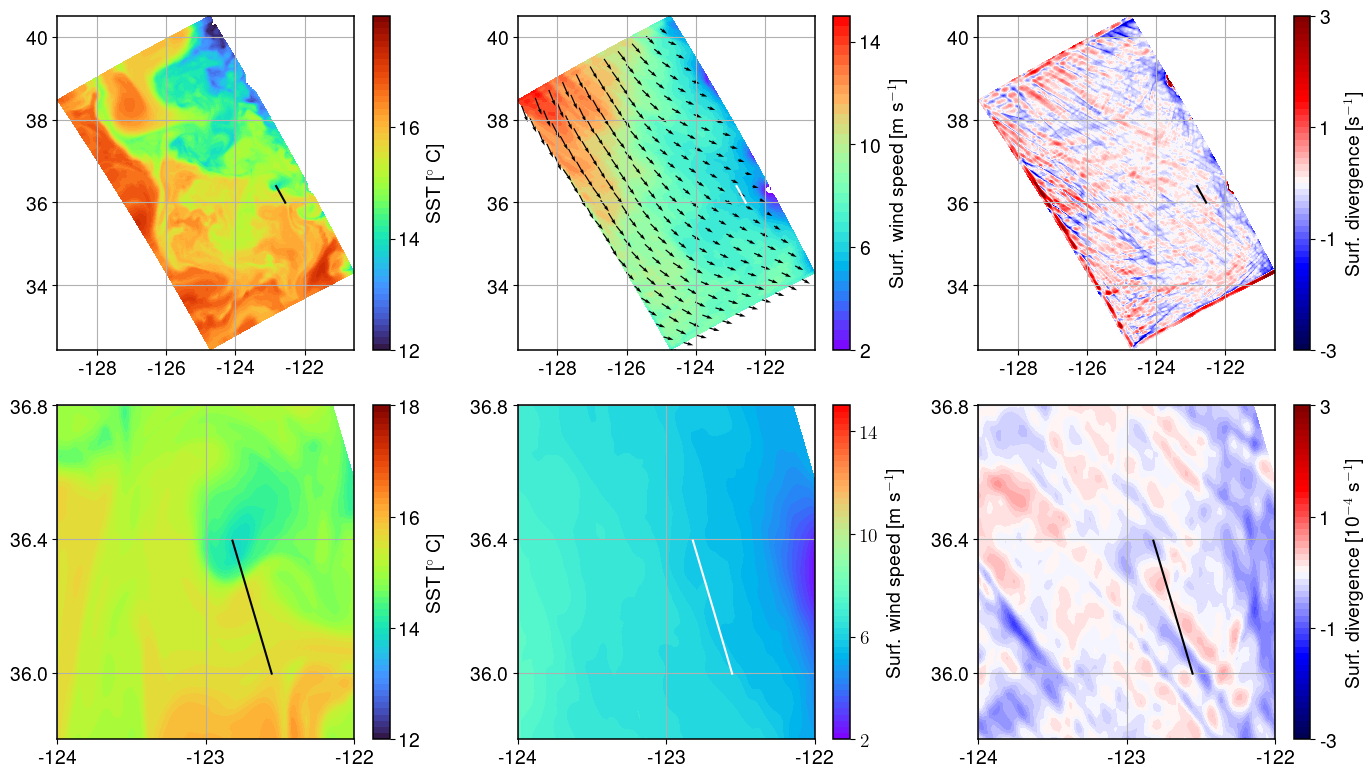

In [265]:
day_s=4

x_sta_lim=182
x_end_lim=183

y_sta_lim=125
y_end_lim=151

tmin=12
tmax=18

windmin=2
windmax=15

divmin=-3
divmax=3


wmin=-1
wmax=1
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
# (sst_full-273.15)[1].plot(

c1=plt.contourf(lon_rho,lat_rho,(sst_full).isel(time_counter=day_s),levels=np.linspace(tmin,tmax,55),cmap='turbo')
cb1=plt.colorbar(c1,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')
cb1.ax.set_yticklabels(np.arange(tmin,tmax,2).astype(str))

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()
plt.yticks([34,36,38,40],labels=np.array([34,36,38,40]))
plt.xticks([-128,-126,-124,-122],labels=np.array([-128,-126,-124,-122]).astype(str))


plt.title('')
plt.subplot(2,3,2)
dec=20
c2=plt.contourf(lon_rho,lat_rho,
    (np.sqrt(u_full.isel(lev_M=1,time_counter=day_s)**2 + v_full.isel(lev_M=1,time_counter=day_s).values**2)),
             levels=np.linspace(windmin,windmax,35),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')


cb2=plt.colorbar(c2,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

cb2.ax.set_yticklabels(np.arange(windmin,windmax,4).astype(str))


plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
           u_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],
           v_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec])
plt.title('')
plt.grid()

plt.yticks([34,36,38,40],labels=np.array([34,36,38,40]))
plt.xticks([-128,-126,-124,-122],labels=np.array([-128,-126,-124,-122]).astype(str))

plt.subplot(2,3,3)
# c5=plt.contourf(lon_rho,lat_rho,
#                 (w_full).isel(lev_W=1,time_counter=day_s)*100,levels=np.linspace(wmin,wmax,55),cmap='seismic',extend='both')
# plt.colorbar(c5,ticks=np.arange(wmin,wmax+2,2),label=r'Surf. w [cm s$^{-1}$]')
# plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
#          lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')


c5=plt.contourf(lon_rho,lat_rho,
                (div_full).isel(lev_M=1,time_counter=day_s)*1e4,levels=np.linspace(divmin,divmax,55),cmap='seismic')
cb5=plt.colorbar(c5,ticks=np.arange(divmin,divmax+2,2),label=r'Surf. divergence [s$^{-1}$]')
cb5.ax.set_yticklabels(np.arange(divmin,divmax+2,2).astype(str))

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.yticks([34,36,38,40],labels=np.array([34,36,38,40]))
plt.xticks([-128,-126,-124,-122],labels=np.array([-128,-126,-124,-122]).astype(str))


plt.subplot(2,3,4)
# (sst_full-273.15)[1].plot(

c1=plt.contourf(lon_rho,lat_rho,(sst_full).isel(time_counter=day_s),levels=np.linspace(tmin,tmax,55),cmap='turbo')
cb1=plt.colorbar(c1,ticks=np.arange(tmin,tmax+2,2),label=r'SST [$^{\circ}$ C]')
cb1.ax.set_yticklabels(np.arange(tmin,tmax+2,2).astype(str))


plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()
plt.ylim(35.8,36.8)
plt.xlim(-124,-122)
plt.yticks([36.8,36.4,36.0],labels=np.array([36.8,36.4,36.0]).astype(str))
plt.xticks([-124,-123,-122],labels=np.array([-124,-123,-122]).astype(str))

plt.title('')
plt.subplot(2,3,5)
dec=10
c2=plt.contourf(lon_rho,lat_rho,
    (np.sqrt(u_full.isel(lev_M=1,time_counter=day_s)**2 + v_full.isel(lev_M=1,time_counter=day_s).values**2)),
             levels=np.linspace(windmin,windmax,55),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')


plt.colorbar(c2,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

# plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
#            u_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],
#            v_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],scale=100)
plt.title('')
plt.grid()
plt.ylim(35.8,36.8)
plt.xlim(-124,-122)
plt.yticks([36.8,36.4,36.0],labels=np.array([36.8,36.4,36.0]).astype(str))
plt.xticks([-124,-123,-122],labels=np.array([-124,-123,-122]).astype(str))
plt.subplot(2,3,6)

c5=plt.contourf(lon_rho,lat_rho,
                (div_full).isel(lev_M=1,time_counter=day_s)*1e4,levels=np.linspace(divmin,divmax,55),cmap='seismic')
cb5=plt.colorbar(c5,ticks=np.arange(divmin,divmax+2,2),label=r'Surf. divergence [10$^{-4}$ s$^{-1}$]')

cb5.ax.set_yticklabels(np.arange(divmin,divmax+2,2).astype(str))


plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.ylim(35.8,36.8)
plt.xlim(-124,-122)
plt.yticks([36.8,36.4,36.0],labels=np.array([36.8,36.4,36.0]).astype(str))
plt.xticks([-124,-123,-122],labels=np.array([-124,-123,-122]).astype(str))

# plt.xticks([-126.25,-125.75])

plt.tight_layout()

In [266]:
Altitude=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim))#.squeeze()
Altitude_m=(Altitude[:,1:].data +  Altitude[:,:-1])/2

Z=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(0,220))
Z_m=Z[:,1:,:,:].data/2 + Z[:,:-1,:,:]/2


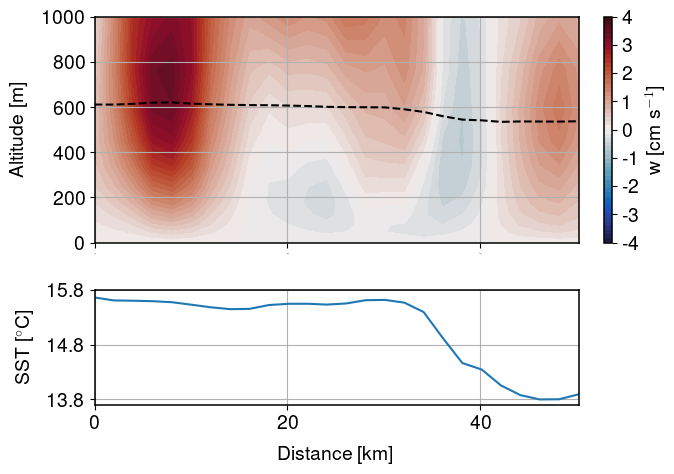

In [267]:
# wmin=-1
# wmax=1
wmin=-4
wmax=4

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])

cb2=plt.contourf(sec_dist,
             Altitude.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             w_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()*100,
                 levels=np.linspace(wmin,wmax,55),cmap=cm.cm.balance)


plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='k',linestyle='--')

plt.grid()

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(wmin,wmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical',label=r'w [cm s$^{-1}$]')

cbar2.ax.set_yticklabels(np.arange(wmin,wmax+1,1).astype(str))

ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

SST_sec=sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()

plt.plot(sec_dist,SST_sec)
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+1,1),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+1,1),2).astype(str))
# ax3.set_ylim(SST_sec.min(),SST_sec.max())

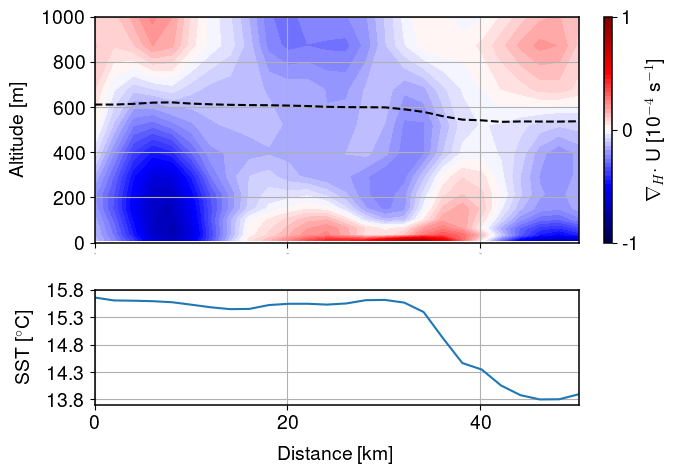

In [268]:

divmin=-1
divmax=1

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])


cb2=plt.contourf(sec_dist,
             Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             div_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                         y_grid_U=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()*1e4,
                 levels=np.linspace(divmin,divmax,55),cmap='seismic')
plt.grid()



plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='k',linestyle='--')


cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(divmin,divmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical',label=r'$\nabla_H \cdot$ U [10$^{-4}$ s$^{-1}$]')
cbar2.ax.set_yticklabels(np.arange(divmin,divmax+1,1).astype(str))


ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),2).astype(str))


In [269]:
# dudz=np.gradient(u_full,
#                  axis=1)/np.gradient(Z_m,axis=1)
# dvdz=np.gradient(v_full,
#                  axis=1)/np.gradient(Z_m,axis=1);VWS_label=r'Vertical wind \\ shear[10$^{-2}$ s$^{-1}$]' #total


dudz=np.gradient(u_full- u_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                                     y_grid_U=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_U','x_grid_U']).values[None,:,None,None],
                 axis=1)/np.gradient(Z_m,axis=1)
dvdz=np.gradient(v_full - v_full.isel(x_grid_V=slice(x_sta_lim,x_end_lim),
                                     y_grid_V=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_V','x_grid_V']).values[None,:,None,None],
                 axis=1)/np.gradient(Z_m,axis=1);VWS_label=r'Vertical wind \\ shear anomaly [10$^{-2}$ s$^{-1}$]' #anomaly

vshear_full=u_full.copy(data=np.sqrt(dudz**2 + dvdz**2)).isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                         y_grid_U=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()

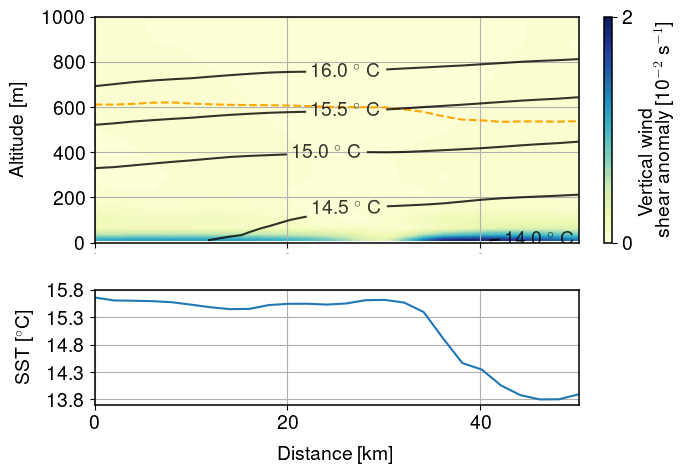

In [270]:

vwsmin=0
vwsmax=2

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

tair_min=14
tair_max=16.5

ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])


cb2=plt.contourf(sec_dist,
             Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             vshear_full*1e2,
                 levels=np.linspace(vwsmin,vwsmax,55),cmap='YlGnBu')
plt.grid()

plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='orange',linestyle='--')


cc=plt.contour(sec_dist,
               Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
               t_air_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),levels=np.arange(tair_min,tair_max,0.5),colors='k',alpha=0.8)
cbr0=plt.clabel(cc, cc.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$ C')

# cbr0=ax0.clabel(cr0, cr0.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$C')
# plt.setp(cc, path_effects=[PathEffects.withStroke(linewidth=0.8,alpha=0.8, foreground="c")])

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(vwsmin,vwsmax+2,2),
                   pad=1,shrink=0.002,orientation='vertical',label=VWS_label)
cbar2.ax.set_yticklabels(np.arange(vwsmin,vwsmax+2,2).astype(str))

ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),2).astype(str))


In [271]:
u_anom_full=(u_full- u_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                                     y_grid_U=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_U','x_grid_U']).values[None,:,None,None])

v_anom_full=(v_full- v_full.isel(x_grid_V=slice(x_sta_lim,x_end_lim),
                                     y_grid_V=slice(y_sta_lim,y_end_lim),
                                     time_counter=day_s).mean(['y_grid_V','x_grid_V']).values[None,:,None,None])

wspeed_anom_full= np.sqrt(u_anom_full**2 + v_anom_full.values**2)


wspeed_full=np.sqrt(u_full**2+v_full.values**2)

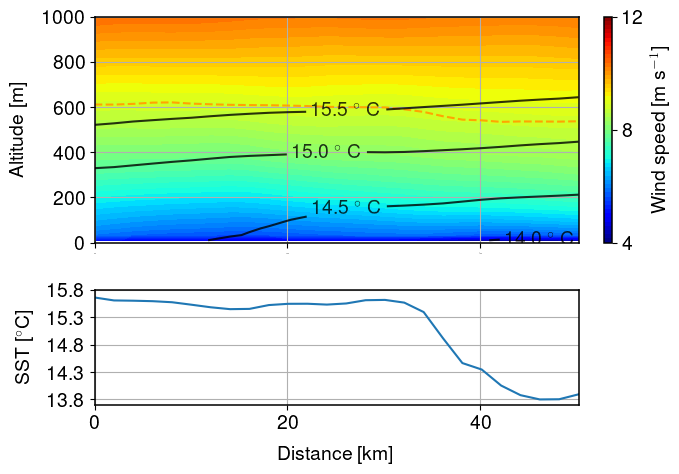

In [277]:

wmin=4
wmax=12

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

tair_min=14
tair_max=16
tair_diff=0.5


ylim=1000
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])


cb2=plt.contourf(sec_dist,
             Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             wspeed_full.isel(x_grid_U=slice(x_sta_lim,x_end_lim),
                         y_grid_U=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),
                 levels=np.linspace(wmin,wmax,55),cmap='jet')
plt.grid()

plt.plot(sec_dist,pbl_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),color='orange',linestyle='--')


cc=plt.contour(sec_dist,
               Altitude_m.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
               t_air_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze(),levels=np.arange(tair_min,tair_max,tair_diff),colors='k',alpha=0.8)
cbr0=plt.clabel(cc, cc.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$ C')

# cbr0=ax0.clabel(cr0, cr0.levels[::1],fontsize=14,inline=True,fmt=r'%1.1f $^{\circ}$C')
# plt.setp(cc, path_effects=[PathEffects.withStroke(linewidth=0.8,alpha=0.8, foreground="c")])

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(wmin,wmax+4,4),
                   pad=1,shrink=0.002,orientation='vertical',label=WS_label)
cbar2.ax.set_yticklabels(np.arange(wmin,wmax+4,4).astype(str))

ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)
ax2.set_yticks(np.arange(0,ylim+ylim//5,ylim//5),labels=np.arange(0,ylim+ylim//5,ylim//5).astype(str))
ax2.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(str),fontsize=0)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)
ax3.set_xticks(np.arange(0,sec_dist.max(),20),labels=np.arange(0,sec_dist.max(),20).astype(int).astype(str))
ax3.set_yticks(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),
               labels=np.round(np.arange(SST_sec.min(),SST_sec.max()+0.5,0.5),2).astype(str))
